# Sub-Pixel Estimation of Circle Parameter

https://docs.google.com/document/d/e/2PACX-1vRUa6n7pokWCJTCjPHTFD-B9GLLVbC-7xapqcFDFd42q7MydQ6z6jQInbJoApMBtozOJC-PWHDrsxp3/pub

.\start_cuda_env.bat

In [1]:
import torch

if torch.cuda.is_available():
    print("PyTorch has access to a CUDA-enabled GPU.")
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Current Device: {torch.cuda.current_device()}")
else:
    print("PyTorch does not have access to a CUDA-enabled GPU and is using the CPU.")

PyTorch has access to a CUDA-enabled GPU.
Device Name: NVIDIA GeForce GTX 1650 Ti
Current Device: 0


In [2]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

Image shape: torch.Size([1, 1, 3000, 4096])


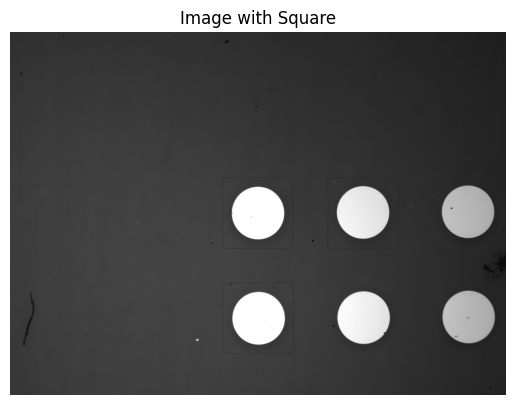

In [3]:
# load image
def load_image(image_path, device):
    img = Image.open(image_path).convert("L") # convert to grayscale
    image = torch.from_numpy(np.array(img)).float().to(device)
    if len(image.shape) == 2: # Grayscale image will be 2D
        image = image.unsqueeze(0).unsqueeze(0) # Add batch and channel dimensions
    elif len(image.shape) == 3:
        image = image.permute(2, 0, 1).unsqueeze(0) # HWC to CHW and add batch dim
    return image



# draw square on image which is a area of interest
def draw_square_on_image(image, top_left, bottom_right, color=0):
    image_with_square = image.clone()
    image_with_square[:, :, top_left[1]:bottom_right[1], top_left[0]] = color # Left edge
    image_with_square[:, :, top_left[1]:bottom_right[1], bottom_right[0]] = color # Right edge
    image_with_square[:, :, top_left[1], top_left[0]:bottom_right[0]] = color # Top edge
    image_with_square[:, :, bottom_right[1], top_left[0]:bottom_right[0]] = color # Bottom edge
    return image_with_square


image_path = r"C:\Users\mj.j\Documents\2025_07_30_13_03_30_inpos_after_tune\0.png"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image = load_image(image_path, device)
print(f"Image shape: {image.shape}") # Should be [1, 1, H, W] for grayscale


distance_between_dots = 867 # distance to adjacent dot in pixels
radius_of_circle = 220 # in pixels
circle_location_tolerance = 70 # in pixels

small_square_length = 13 # in pixels
small_square_height = 5

center_dot_image_location = [int(image.shape[3] / 2), int(image.shape[2] / 2)]
right_dot_image_location = [center_dot_image_location[0] + distance_between_dots, center_dot_image_location[1]]
bottom_dot_image_location = [center_dot_image_location[0], center_dot_image_location[1] + distance_between_dots]

half_length_of_square = radius_of_circle + circle_location_tolerance
center_dot_square_top_left = (int(center_dot_image_location[0] - half_length_of_square), int(center_dot_image_location[1] - half_length_of_square))
center_dot_square_bottom_right = (int(center_dot_image_location[0] + half_length_of_square), int(center_dot_image_location[1] + half_length_of_square))

right_dot_square_top_left = (int(right_dot_image_location[0] - half_length_of_square), int(right_dot_image_location[1] - half_length_of_square))
right_dot_square_bottom_right = (int(right_dot_image_location[0] + half_length_of_square), int(right_dot_image_location[1] + half_length_of_square))

bottom_dot_square_top_left = (int(bottom_dot_image_location[0] - half_length_of_square), int(bottom_dot_image_location[1] - half_length_of_square))
bottom_dot_square_bottom_right = (int(bottom_dot_image_location[0] + half_length_of_square), int(bottom_dot_image_location[1] + half_length_of_square))

# top_left = (1828,1280)
# bottom_right = (2268,1720)
circle_edge_left_top = (center_dot_image_location[0] - radius_of_circle - small_square_length, center_dot_image_location[1]  - small_square_height)
circle_edge_left_bottom = (center_dot_image_location[0] - radius_of_circle + small_square_length, center_dot_image_location[1]  + small_square_height)

image_with_square = draw_square_on_image(image, center_dot_square_top_left, center_dot_square_bottom_right)
image_with_square = draw_square_on_image(image_with_square, circle_edge_left_top, circle_edge_left_bottom, color=0)
image_with_square = draw_square_on_image(image_with_square, right_dot_square_top_left, right_dot_square_bottom_right)
image_with_square = draw_square_on_image(image_with_square, bottom_dot_square_top_left, bottom_dot_square_bottom_right)

# plt.figure(figsize=(80, 80))
plt.imshow(image_with_square.cpu().squeeze(), cmap='gray')
plt.title("Image with Square")
plt.axis('off') # Hide axes
plt.show()


Circle fit results saved to C:\Users\mj.j\Documents\2025_07_30_13_03_30_inpos_after_tune\circle_fit_results.csv


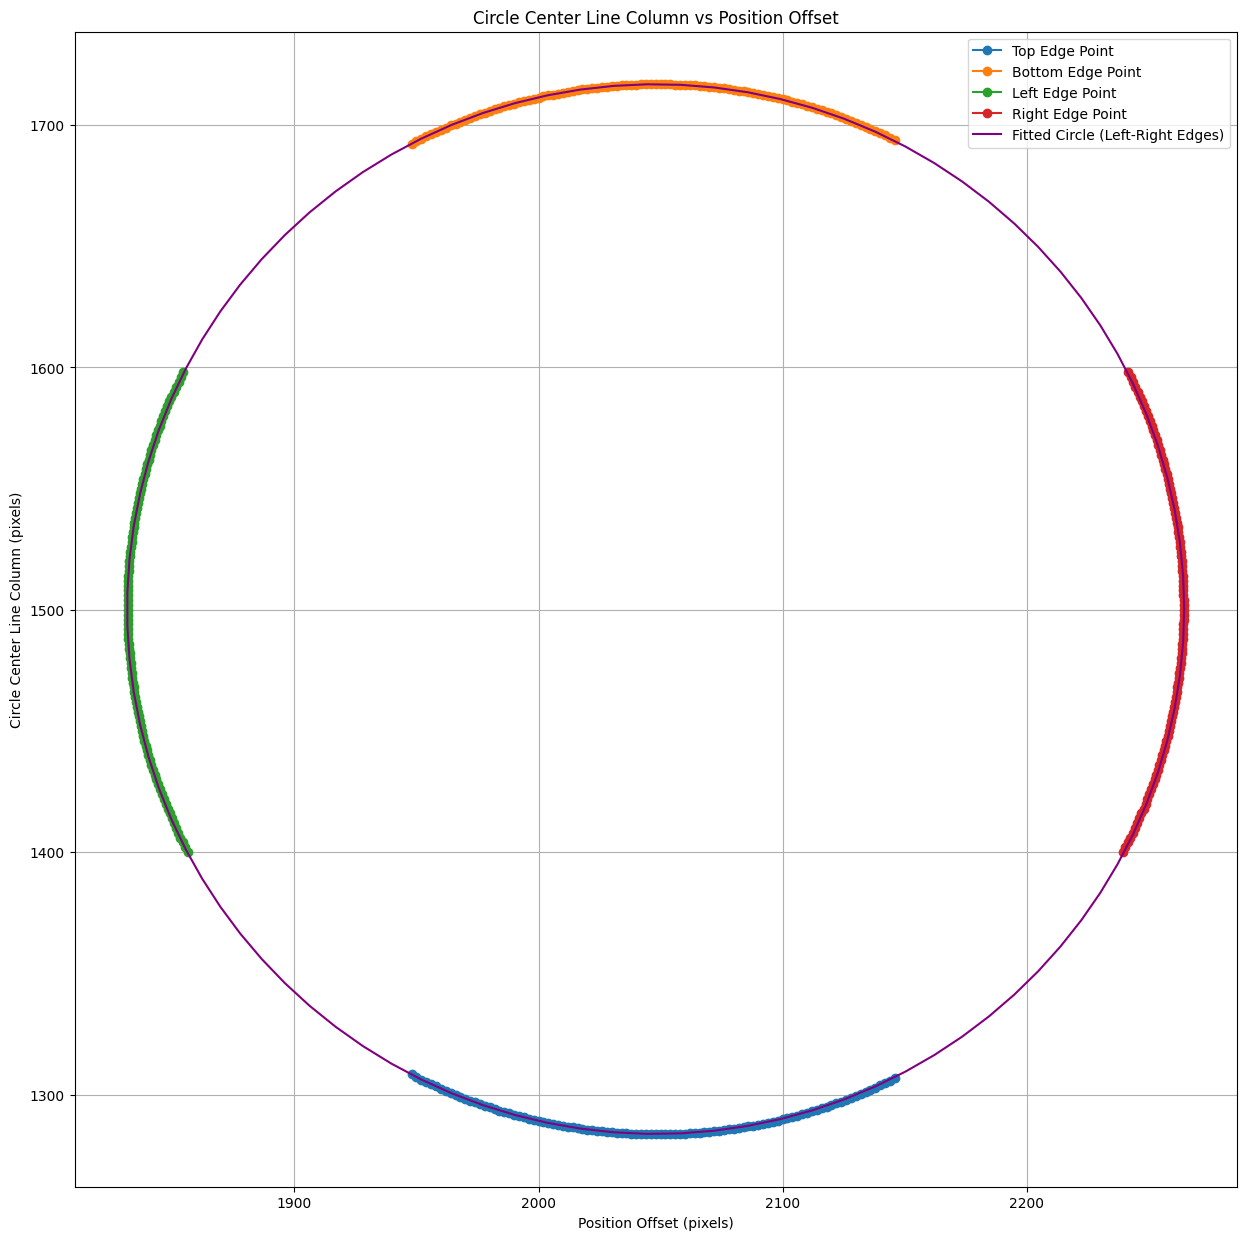

[[   0.        1500.2702152 2047.9390392  216.5591144]
 [   1.        1500.3030601 2047.9663656  216.5583799]
 [   2.        1500.2574571 2047.9686981  216.5607091]
 [   3.        1500.2772462 2047.9662506  216.5598266]
 [   4.        1500.2784019 2047.9669976  216.5612502]
 [   5.        1500.2733174 2047.9703165  216.5606495]
 [   6.        1500.2679334 2047.9672121  216.5604612]
 [   7.        1500.253705  2047.9608725  216.5591835]
 [   8.        1500.2697399 2047.9839368  216.5601408]
 [   9.        1500.2850232 2047.9886376  216.5597304]
 [  10.        1500.2863385 2048.0039944  216.5601338]
 [  11.        1500.2758529 2048.021148   216.5594476]
 [  12.        1500.3035912 2047.9775606  216.5621081]
 [  13.        1500.2765662 2048.000031   216.5606657]
 [  14.        1500.2659459 2047.9801558  216.56002  ]
 [  15.        1500.2557775 2048.0166831  216.5601992]
 [  16.        1500.2532337 2047.9777628  216.5600298]
 [  17.        1500.3131113 2047.9471745  216.5598879]
 [  18.   

In [5]:
from scipy.optimize import curve_fit
import os
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import csv




# load image
def load_image(image_path, device):
    img = Image.open(image_path).convert("L") # convert to grayscale
    image = torch.from_numpy(np.array(img)).float().to(device)
    if len(image.shape) == 2: # Grayscale image will be 2D
        image = image.unsqueeze(0).unsqueeze(0) # Add batch and channel dimensions
    elif len(image.shape) == 3:
        image = image.permute(2, 0, 1).unsqueeze(0) # HWC to CHW and add batch dim
    return image


def gaussian(x, amp, mean, stddev, offset):
    return amp * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2)) + offset

# Fit the gradient of the edge to a Gaussian to find the sub-pixel location of the edge
def fit_gaussian(x, y): 

    #  def gaussian(x, amp, mean, stddev, offset):
    #     return amp * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2)) + offset

    # Check if the peak is positive or negative (a dip)
    if np.abs(np.max(y)) > np.abs(np.min(y)):
        # It's a positive peak
        initial_guess = [np.max(y) - np.median(y), x[np.argmax(y)], 1.0, np.median(y)]
    else:
        # It's a negative peak (dip)
        initial_guess = [np.min(y) - np.median(y), x[np.argmin(y)], 1.0, np.median(y)]

    try:
        popt, _ = curve_fit(gaussian, x, y, p0=initial_guess)
        return popt  # Returns the parameters of the fitted Gaussian
    except RuntimeError:
        print("Error - curve_fit failed")
        return None
    

# generate guissian curve for plotting
def generate_gaussian_curve(gaussian_params, x_data):
    if gaussian_params is None:
        return None
    return gaussian_params[0] * np.exp(-((x_data - gaussian_params[1]) ** 2) / (2 * gaussian_params[2] ** 2)) + gaussian_params[3]


def plot_with_fitted_curve(x_data, y_data):
    plt.figure(figsize=(10, 6))
    plt.plot(x_data, y_data, label='Data', linestyle='--', color='red')
    plt.title("Data and Fitted Gaussian Curve")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.legend()
    plt.grid()
    plt.show()

# plot the column sum and its gradient
def plot_column_sum_and_gradient(column_sum, gradient):
    plt.figure(figsize=(10, 6))
    plt.plot(column_sum, label='Column Sum', color='blue')
    plt.plot(gradient, label='Gradient', linestyle='--', color='red')
    plt.title("Column Sum and its Gradient")
    plt.xlabel("Column Index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid()
    plt.show()


# Calculate the edge location using Gaussian fitting
def edge_location_X(circle_edge_1, circle_edge_2,image):
# crop image to square
    cropped_image = image[:, :, circle_edge_1[1]:circle_edge_2[1], circle_edge_1[0]:circle_edge_2[0]]
    # calculate the values of the square along columns 
    circle_edge_column_sum = torch.sum(cropped_image, dim=2).squeeze()
    # convert to numpy for processing
    circle_edge_column_sum_values = circle_edge_column_sum.cpu().squeeze().numpy()
    # calculate the gradient of the column sum
    circle_edge_column_sum_gradient = np.gradient(circle_edge_column_sum_values)
    # interpolate x values for fitting by 100 times
    x_data_interp = np.linspace(0, len(circle_edge_column_sum_gradient) - 1, 400)
    x_samples = np.arange(len(circle_edge_column_sum_gradient))
    
    # fit the gradient to a Gaussian
    gaussian_params_column = fit_gaussian(x_samples, circle_edge_column_sum_gradient)
    
    if gaussian_params_column is not None:
        # print("gaussian_params_column:",round(gaussian_params_column[1],7))
    
        #if gaussian_params is not None:
        # plot_column_sum_and_gradient(circle_edge_column_sum_values, circle_edge_column_sum_gradient)
        # fitted_curve = generate_gaussian_curve(gaussian_params_column, x_data_interp)
        # plot_with_fitted_curve(x_data_interp, fitted_curve)
        return (round(gaussian_params_column[1],7))
    
    else:
        print("Gaussian fitting failed for column data.")
        return None


# Calculate the edge location using Gaussian fitting
def edge_location_Y(circle_edge_1, circle_edge_2,image):
# crop image to square
    cropped_image = image[:, :, circle_edge_1[1]:circle_edge_2[1], circle_edge_1[0]:circle_edge_2[0]]
    # calculate the values of the square along rows
    circle_edge_row_sum = torch.sum(cropped_image, dim=3).squeeze()

    # convert to numpy for processing
    # circle_edge_row_sum_values = circle_edge_row_sum.cpu().squeeze().numpy()
    # circle_edge_row_sum_gradient = np.gradient(circle_edge_row_sum_values) # calculate the gradient of the row sum
    
    circle_edge_row_sum_gradient_tensor = torch.gradient(circle_edge_row_sum)[0] # Get the gradient tensor

    # convert to numpy for processing
    # circle_edge_row_sum_values = circle_edge_row_sum.cpu().squeeze().numpy()
    circle_edge_row_sum_gradient = circle_edge_row_sum_gradient_tensor.cpu().numpy()

    
    # interpolate x values for fitting by 100 times
    # x_data_interp = np.linspace(0, len(circle_edge_row_sum_gradient) - 1, 400)
    x_samples = np.arange(len(circle_edge_row_sum_gradient))

    # fit the gradient to a Gaussian
    gaussian_params_row = fit_gaussian(x_samples, circle_edge_row_sum_gradient)

    if gaussian_params_row is not None:
        # print("gaussian_params_row:",round(gaussian_params_row[1],7))
    
        #if gaussian_params is not None:
        # plot_column_sum_and_gradient(circle_edge_row_sum_values, circle_edge_row_sum_gradient)
        # fitted_curve = generate_gaussian_curve(gaussian_params_row, x_data_interp)
        # plot_with_fitted_curve(x_data_interp, fitted_curve)
        return (round(gaussian_params_row[1],7))
    
    else:
        print("Gaussian fitting failed for row data.")
        return None


# circle fitting function
def fit_circle_to_points(points):
    points = np.array(points)
    x = points[:, 0]
    y = points[:, 1]

    A = np.c_[x, y, np.ones(x.shape[0])]
    b = x**2 + y**2

    # Solve the linear system A * params = b
    params, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)

    if rank < 3:
        print("Circle fitting failed: insufficient rank.")
        return None, None, None

    # Extract circle parameters
    c_x = params[0] / 2
    c_y = params[1] / 2
    radius = np.sqrt(params[2] + c_x**2 + c_y**2)

    return c_x, c_y, radius




def plot_and_save_circle_fit(left_edge_point_x, left_edge_point_y, right_edge_point_x, right_edge_point_y, c_x_lr, c_y_lr, radius_lr):
    # # # drow the fitted circle on the image
    theta = np.linspace(0, 2 * np.pi, 100)
    circle_x_lr = c_x_lr + radius_lr * np.cos(theta)
    circle_y_lr = c_y_lr + radius_lr * np.sin(theta) 
    
    # # # plot the circle center line column vs position offset
    plt.figure(figsize=(15, 15))
    plt.plot(top_edge_point_x, top_edge_point_y, marker='o', label='Top Edge Point')
    plt.plot(bottom_edge_point_x, bottom_edge_point_y, marker='o', label='Bottom Edge Point')
    plt.plot(left_edge_point_x, left_edge_point_y, marker='o', label='Left Edge Point')
    plt.plot(right_edge_point_x, right_edge_point_y, marker='o', label='Right Edge Point')
    plt.plot(circle_x_lr, circle_y_lr, label='Fitted Circle (Left-Right Edges)', color='purple')
    # plt.axhline(y=np.mean(circle_center_line_column), color='g', linestyle='--', label='Ideal Circle Center Line Column')
    plt.title("Circle Center Line Column vs Position Offset")
    plt.xlabel("Position Offset (pixels)")
    plt.ylabel("Circle Center Line Column (pixels)")
    plt.grid()
    
    plt.legend()
    plt.savefig(r"C:\Users\mj.j\Documents\2025_07_30_13_03_30_inpos_after_tune\circle_fit_plot_low_res.png", bbox_inches='tight')
    
    plt.show(block=True) 
    
    



# ==========================
# main part 1
# ==========================


radius_of_circle = 216 # 216
circle_location_tolerance = 70
half_length_of_square = radius_of_circle + circle_location_tolerance
small_square_length = 30 # in pixels
small_square_height = 8
Y_axis_location_offset = 0 # to shift the square up or down for testing
position_offset_range = range(-100, 100, 2)
image_path = r"C:\Users\mj.j\Documents\2025_07_30_13_03_30_inpos_after_tune\0.png"



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_dir = os.path.dirname(image_path)
csv_file_path = os.path.join(base_dir, "circle_fit_results.csv")
with open(csv_file_path, mode='w+', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Image Index", "Circle Center Y", "Circle Center X", "Circle Radius"])

# close file
file.close()

for i in range (0,32,1) : # just process one image for now
    image_index = i
    image_name = f"{image_index}.png"
    image_path_full = os.path.join(base_dir, image_name)

    image = load_image(image_path_full, device)
    # print(f"Image shape: {image.shape}") # Should be [1, 1, H, W] for grayscale

    center_dot_image_location = [int(image.shape[3] / 2), int(image.shape[2] / 2)]
    # print(f"Center dot location: {center_dot_image_location}")

    position_offset = 0 # to shift the square left or right for testing
    # numpy array to store the circle center line column vs position offset
    left_edge_point_x = []
    left_edge_point_y = []
    right_edge_point_x = []
    right_edge_point_y = []

    for position_offset in position_offset_range:    
        circle_edge_left_top = (center_dot_image_location[0] - radius_of_circle - small_square_length, center_dot_image_location[1] + position_offset - small_square_height)
        circle_edge_left_bottom = (center_dot_image_location[0] - radius_of_circle + small_square_length, center_dot_image_location[1] + position_offset + small_square_height)
        subpixel_offset_x = edge_location_X(circle_edge_left_top, circle_edge_left_bottom, image)
        edge_location_value_1 = np.array([circle_edge_left_top[0] + subpixel_offset_x, center_dot_image_location[1] + position_offset])

        circle_edge_right_top = (center_dot_image_location[0] + radius_of_circle - small_square_length, center_dot_image_location[1] + position_offset - small_square_height)
        circle_edge_right_bottom = (center_dot_image_location[0] + radius_of_circle + small_square_length, center_dot_image_location[1] + position_offset + small_square_height)
        subpixel_offset_x = edge_location_X(circle_edge_right_top, circle_edge_right_bottom, image)
        edge_location_value_2 = np.array([circle_edge_right_top[0] + subpixel_offset_x, center_dot_image_location[1] + position_offset])
        # print(edge_location_value_2)

        left_edge_point_x.append(edge_location_value_1[0])
        left_edge_point_y.append(edge_location_value_1[1])
        right_edge_point_x.append(edge_location_value_2[0])
        right_edge_point_y.append(edge_location_value_2[1])
        # print(f"X position: {edge_location_value_1}, edge_location: {circle_center_line_column[-1]}")


    position_offset = 0

    top_edge_point_x = []
    top_edge_point_y = []
    bottom_edge_point_x = []
    bottom_edge_point_y = []

    for position_offset in position_offset_range:
        circle_edge_top_top = (center_dot_image_location[0] + position_offset - small_square_height, center_dot_image_location[1] - radius_of_circle - small_square_length)
        circle_edge_top_bottom = (center_dot_image_location[0] + position_offset + small_square_height, center_dot_image_location[1] - radius_of_circle + small_square_length)
        subpixel_offset_y = edge_location_Y(circle_edge_top_top, circle_edge_top_bottom, image)
        edge_location_value_1 = np.array([center_dot_image_location[0] + position_offset, circle_edge_top_top[1] + subpixel_offset_y])


        circle_edge_bottom_top = (center_dot_image_location[0] + position_offset - small_square_height, center_dot_image_location[1] + radius_of_circle - small_square_length)
        circle_edge_bottom_bottom = (center_dot_image_location[0] + position_offset + small_square_height, center_dot_image_location[1] + radius_of_circle + small_square_length)
        subpixel_offset_y = edge_location_Y(circle_edge_bottom_top, circle_edge_bottom_bottom, image)
        edge_location_value_2 = np.array([center_dot_image_location[0] + position_offset, circle_edge_bottom_top[1] + subpixel_offset_y])

        top_edge_point_x.append(edge_location_value_1[0])
        top_edge_point_y.append(edge_location_value_1[1])
        bottom_edge_point_x.append(edge_location_value_2[0])
        bottom_edge_point_y.append(edge_location_value_2[1])
        # print("Top edge location:", circle_edge_top_top, circle_edge_top_bottom)
        # print("Bottom edge location:", circle_edge_bottom_top, circle_edge_bottom_bottom)


    # # fit circle to left and right edge points
    left_right_edge_points = list(zip(left_edge_point_x, left_edge_point_y)) + list(zip(right_edge_point_x, right_edge_point_y)) + list(zip(top_edge_point_x, top_edge_point_y)) + list(zip(bottom_edge_point_x, bottom_edge_point_y))
    c_x_lr, c_y_lr, radius_lr = fit_circle_to_points(left_right_edge_points)
    # print(f"Fitted Circle (Left-Right Edges): Center=({c_x_lr:.6f}, {c_y_lr:.6f}), Radius={radius_lr:.6f}")




    # save location data to csv file
    # need to save in numarical fomat with 7 decimal places
    # image_index, c_y_lr:.6f, c_x_lr:.6f, radius_lr:.6f

    with open(csv_file_path, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([image_index, f"{c_y_lr:.7f}", f"{c_x_lr:.7f}", f"{radius_lr:.7f}"])
    file.close()

print(f"Circle fit results saved to {csv_file_path}")


plot_and_save_circle_fit(left_edge_point_x, left_edge_point_y, right_edge_point_x, right_edge_point_y, c_x_lr, c_y_lr, radius_lr)



# part 2

csv_file_path = r"C:\Users\mj.j\Documents\2025_07_30_13_03_30_inpos_after_tune\circle_fit_results.csv"

# open the csv file to check numpy remove the fitst line

# read the data in numarical format not sting format. 

data = np.genfromtxt(csv_file_path, delimiter=',', skip_header=1)

# convert to numpy array normal decimal point format not scientific format up to 7 decimal places
data_array = np.array(data, dtype=np.float64)
np.set_printoptions(precision=7, suppress=True)
# print(data_array.shape)

print(data_array)


# calculate the mean of each column
mean_values = np.mean(data_array, axis=0)
# print("Mean values of each column:", mean_values)

# calculate the standard deviation of each column
std_dev_values = np.std(data_array, axis=0)

# print("Standard deviation of each column:", std_dev_values)

multiplication_factor = 1000000*(0.25 / mean_values[3]) # 1 pixel = 1155.828527 um
multiplication_factor = 1152.42
# print("Multiplication factor:", multiplication_factor)
# print("Standard deviation of radius in nanometers:", std_dev_values[3]*multiplication_factor)
std_dev_radius_nano = [std_dev_values[3]*multiplication_factor, std_dev_values[3]*multiplication_factor*3]
std_dev_X_nano = [std_dev_values[2]*multiplication_factor, std_dev_values[2]*multiplication_factor*3]
std_dev_Y_nano = [std_dev_values[1]*multiplication_factor, std_dev_values[1]*multiplication_factor*3]








In [84]:


def combine_plots(cropped_image, circle_edge_column_sum_values):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
    # Plot cropped image
    ax1.imshow(cropped_image.cpu().squeeze(), cmap='gray', aspect='auto')
    ax1.set_title("Cropped Image")
    # ax1.set_xlabel("X-axis (pixels)")
    ax1.set_ylabel("Y-axis (pixels)")
    ax1.tick_params(axis='both', which='major', labelsize=12)

    # Plot column sum values
    ax2.plot(circle_edge_column_sum_values, label='Column Sum', color='blue')
    ax2.set_title("Circle Edge Column Sum Values")
    ax2.set_xlabel("Column Index")
    ax2.set_ylabel("Value")
    ax2.legend()
    ax2.grid()

    plt.tight_layout()
    plt.show()

def plot_column_sum_and_gradient(column_sum, gradient):
    plt.figure(figsize=(10, 6))
    plt.scatter(np.arange(len(column_sum)), column_sum, label='Column Sum', marker='.', color= 'blue')
    plt.plot(column_sum, label='Column Sum',linestyle = '--', color='lightblue')
    plt.scatter(np.arange(len(gradient)), gradient, label='Gradient', marker='.', color='red')
    plt.plot(gradient, label='Gradient', linestyle='--', color='salmon')
    plt.title("Column Sum and its Gradient")
    plt.xlabel("Column Index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid()
    plt.show()


def plot_with_fitted_curve(x_data_interp, fitted_curve,gradient) :
    plt.figure(figsize=(10, 6))
    plt.plot(gradient, label='Gradient', linestyle='--', color='salmon')
    plt.plot(x_data_interp, fitted_curve, label='Fitted Gaussian Curve', color='green')
    plt.title("Fitted Gaussian Curve")
    plt.xlabel("X-axis")
    plt.ylabel("Fitted Value")
    plt.legend()
    plt.grid()
    plt.show()

# Calculate the edge location using Gaussian fitting
def edge_location_X1(circle_edge_1, circle_edge_2,image):
# crop image to square
    cropped_image = image[:, :, circle_edge_1[1]:circle_edge_2[1], circle_edge_1[0]:circle_edge_2[0]]
    
    # calculate the values of the square along columns 
    circle_edge_column_sum = torch.sum(cropped_image, dim=2).squeeze()
    # convert to numpy for processing
    circle_edge_column_sum_values = circle_edge_column_sum.cpu().squeeze().numpy()
    # plot_croped_image(cropped_image)
    # plot_circle_edge_column_sum_values(circle_edge_column_sum_values/16)
    combine_plots(cropped_image, circle_edge_column_sum_values/16)
    # calculate the gradient of the column sum
    circle_edge_column_sum_gradient = np.gradient(circle_edge_column_sum_values)
    # interpolate x values for fitting by 100 times
    x_data_interp = np.linspace(0, len(circle_edge_column_sum_gradient) - 1, 6000)
    x_samples = np.arange(len(circle_edge_column_sum_gradient))
    plot_column_sum_and_gradient(circle_edge_column_sum_values/16, circle_edge_column_sum_gradient/3)
    
    # fit the gradient to a Gaussian
    gaussian_params_column = fit_gaussian(x_samples, circle_edge_column_sum_gradient)
    
    # plot gaussian parameters column with x_data_interp values
    if gaussian_params_column is not None:
        fitted_curve = generate_gaussian_curve(gaussian_params_column, x_data_interp)
        plot_with_fitted_curve(x_data_interp, fitted_curve,circle_edge_column_sum_gradient) 

    if gaussian_params_column is not None:
        # print("gaussian_params_column:",round(gaussian_params_column[1],7))
    
        #if gaussian_params is not None:
        # plot_column_sum_and_gradient(circle_edge_column_sum_values, circle_edge_column_sum_gradient)
        # fitted_curve = generate_gaussian_curve(gaussian_params_column, x_data_interp)
        # plot_with_fitted_curve(x_data_interp, fitted_curve)
        return (round(gaussian_params_column[1],7))
    
    else:
        print("Gaussian fitting failed for column data.")
        return None

position_offset: 0 , center_dot_image_location[0]: 2048 , center_dot_image_location[1]: 1500 , small_square_height: 8 , small_square_length: 30 , radius_of_circle: 216


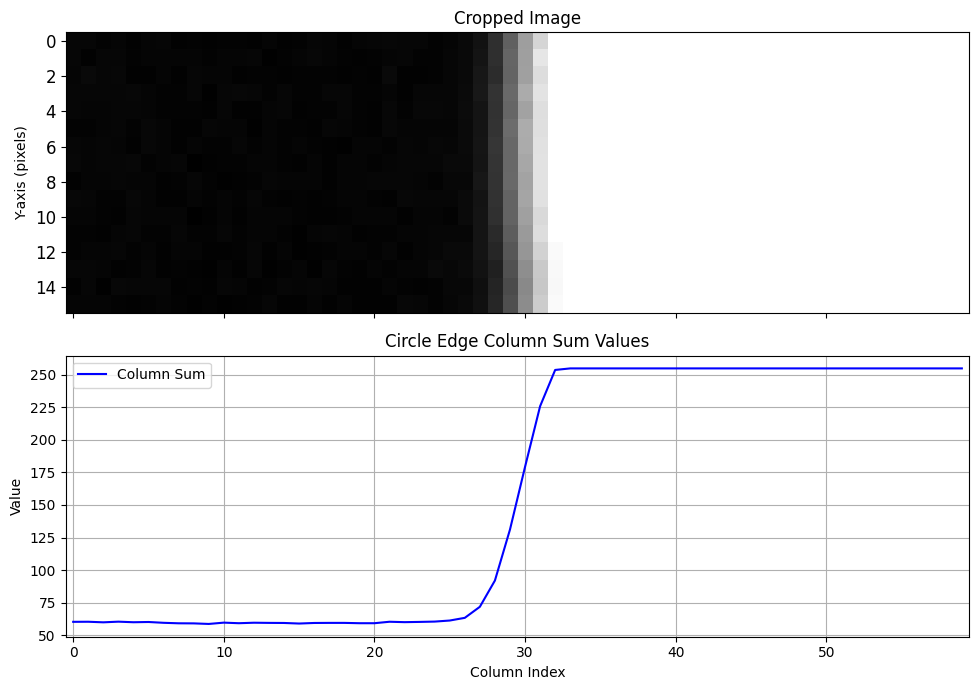

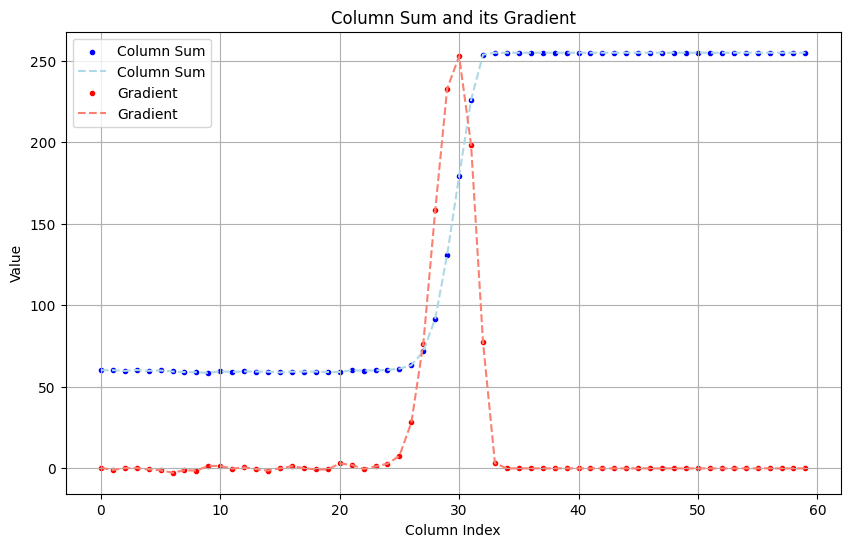

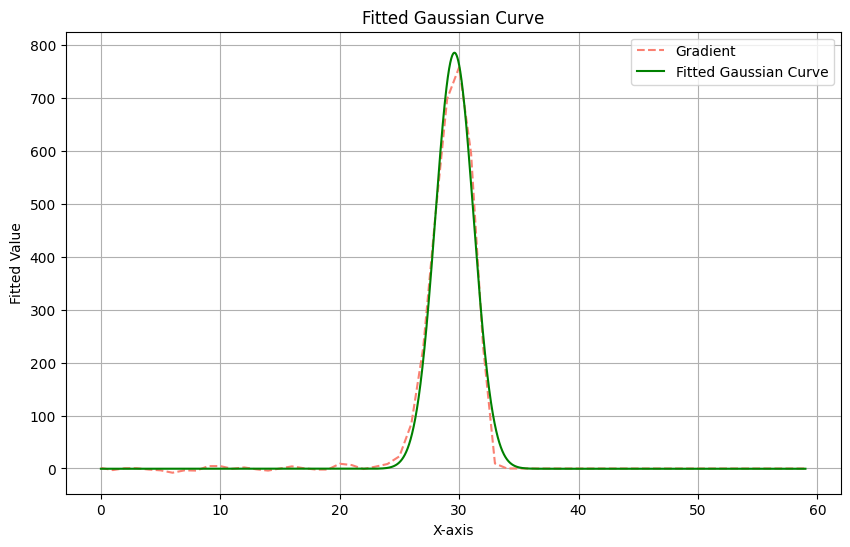

(1802, 1492)
(1862, 1508)
29.609694


In [85]:
radius_of_circle = 216 # 216
circle_location_tolerance = 70
half_length_of_square = radius_of_circle + circle_location_tolerance
small_square_length = 30 # in pixels
small_square_height = 8
position_offset = 0
print("position_offset:", position_offset, ", center_dot_image_location[0]:", center_dot_image_location[0], ", center_dot_image_location[1]:", center_dot_image_location[1], ", small_square_height:", small_square_height, ", small_square_length:", small_square_length, ", radius_of_circle:", radius_of_circle)

circle_edge_left_top = (center_dot_image_location[0] - radius_of_circle - small_square_length, center_dot_image_location[1] + position_offset - small_square_height)
circle_edge_left_bottom = (center_dot_image_location[0] - radius_of_circle + small_square_length, center_dot_image_location[1] + position_offset + small_square_height)
subpixel_offset_x = edge_location_X1(circle_edge_left_top, circle_edge_left_bottom, image)

print(circle_edge_left_top)
print(circle_edge_left_bottom)
print(subpixel_offset_x)


In [6]:
print(std_dev_radius_nano[0],std_dev_radius_nano[1])
print(std_dev_X_nano[0],std_dev_X_nano[1])
print(std_dev_Y_nano[0],std_dev_Y_nano[1])

0.8957204687506289 2.687161406251887
23.318747226128405 69.95624167838521
18.2198582094729 54.659574628418696


In [92]:
# files in the base directory
base_dir_files = os.listdir(base_dir)
print(base_dir_files)

['0.png', '1.png', '10.png', '11.png', '12.png', '13.png', '14.png', '15.png', '16.png', '17.png', '18.png', '19.png', '2.png', '20.png', '21.png', '22.png', '23.png', '24.png', '25.png', '26.png', '27.png', '28.png', '29.png', '3.png', '30.png', '31.png', '4.png', '5.png', '6.png', '7.png', '8.png', '9.png', 'circle_fit_plot.png', 'circle_fit_plot_low_res.png', 'circle_fit_results.csv', 'circle_parameters.csv', 'radius_std.png', 'x_and_y_position.png', 'x_and_y_position_circle.png']


In [93]:
halcon_parameters = os.path.join(base_dir, "circle_parameters.csv")

halcon_parameters_numpy = np.genfromtxt(halcon_parameters, delimiter=',', skip_header=1)

# convert to numpy array normal decimal point format not scientific format up to 7 decimal places
halcon_values_array = np.array(halcon_parameters_numpy, dtype=np.float64)
np.set_printoptions(precision=7, suppress=True)
print(halcon_values_array.shape)
print(halcon_values_array)



(37, 4)
[[   0.       1500.293883 2047.956051  216.29467 ]
 [   1.       1500.326847 2047.986005  216.293248]
 [   2.       1500.282525 2047.985588  216.296527]
 [   3.       1500.300897 2047.983045  216.294687]
 [   4.       1500.302539 2047.982802  216.296764]
 [   5.       1500.297238 2047.988126  216.296156]
 [   6.       1500.290932 2047.985571  216.297305]
 [   7.       1500.277825 2047.978607  216.296085]
 [   8.       1500.294183 2048.001171  216.294192]
 [   9.       1500.310004 2048.007567  216.295248]
 [  10.       1500.313379 2048.020997  216.294512]
 [  11.       1500.300937 2048.037889  216.294973]
 [  12.       1500.329083 2047.996247  216.296639]
 [  13.       1500.29801  2048.018212  216.295773]
 [  14.       1500.291082 2047.997475  216.294039]
 [  15.       1500.280811 2048.035672  216.294919]
 [  16.       1500.277934 2047.994256  216.292489]
 [  17.       1500.33751  2047.965653  216.294703]
 [  18.       1500.288998 2047.97888   216.295642]
 [  19.       1500.2880

Halcon parameters: [1500.293883 1500.326847 1500.282525 1500.300897 1500.302539 1500.297238
 1500.290932 1500.277825 1500.294183 1500.310004 1500.313379 1500.300937
 1500.329083 1500.29801  1500.291082 1500.280811 1500.277934 1500.33751
 1500.288998 1500.288002 1500.281513 1500.315634 1500.306597 1500.308611
 1500.321749 1500.318023 1500.312768 1500.30249  1500.306436 1500.305033
 1500.32125  1500.329554]


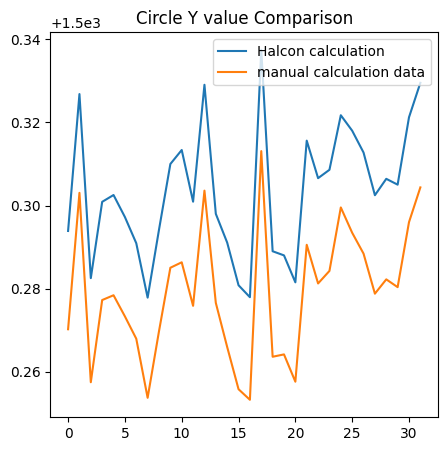

In [94]:
# prints the first column up the row 33

print("Halcon parameters:", halcon_values_array[:32,1])
plt.figure(figsize=(5, 5))
plt.plot(halcon_values_array[:32,0],halcon_values_array[:32,1], label='Halcon calculation')
plt.plot(data_array[:32,0],data_array[:32,1] , label='manual calculation data')
plt.title("Circle Y value Comparison")
plt.legend()

Halcon parameters: [1500.293883 1500.326847 1500.282525 1500.300897 1500.302539 1500.297238
 1500.290932 1500.277825 1500.294183 1500.310004 1500.313379 1500.300937
 1500.329083 1500.29801  1500.291082 1500.280811 1500.277934 1500.33751
 1500.288998 1500.288002 1500.281513 1500.315634 1500.306597 1500.308611
 1500.321749 1500.318023 1500.312768 1500.30249  1500.306436 1500.305033
 1500.32125  1500.329554]


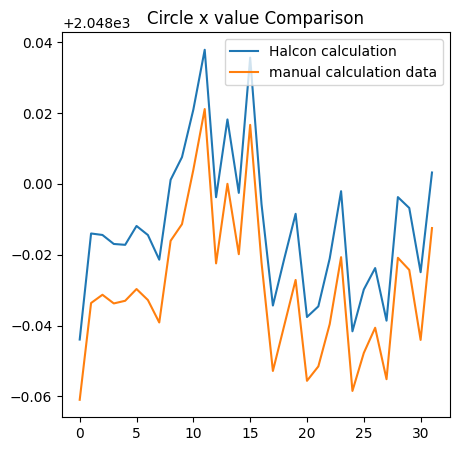

In [95]:
# prints the first column up the row 33

print("Halcon parameters:", halcon_values_array[:32,1])
plt.figure(figsize=(5, 5))
plt.plot(halcon_values_array[:32,0],halcon_values_array[:32,2], label='Halcon calculation')
plt.plot(data_array[:32,0],data_array[:32,2] , label='manual calculation data')
plt.title("Circle x value Comparison")
plt.legend()

Halcon parameters: [1500.293883 1500.326847 1500.282525 1500.300897 1500.302539 1500.297238
 1500.290932 1500.277825 1500.294183 1500.310004 1500.313379 1500.300937
 1500.329083 1500.29801  1500.291082 1500.280811 1500.277934 1500.33751
 1500.288998 1500.288002 1500.281513 1500.315634 1500.306597 1500.308611
 1500.321749 1500.318023 1500.312768 1500.30249  1500.306436 1500.305033
 1500.32125  1500.329554]


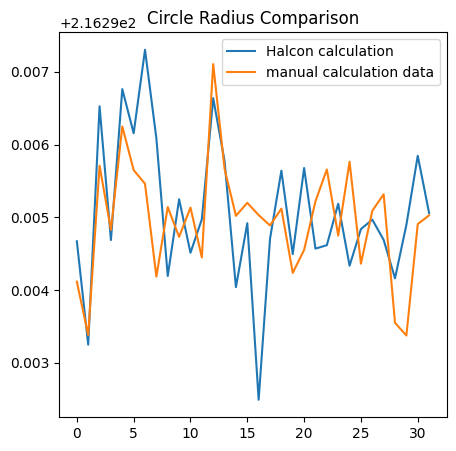

In [96]:
# prints the first column up the row 33

print("Halcon parameters:", halcon_values_array[:32,1])
plt.figure(figsize=(5, 5))
plt.plot(halcon_values_array[:32,0],halcon_values_array[:32,3], label='Halcon calculation')
plt.plot(data_array[:32,0],data_array[:32,3] - 0.265 , label='manual calculation data')
plt.title("Circle Radius Comparison")
plt.legend()